# Exploratory Data Analysis


## 2. Bivariate Analysis

### Investigations

1. Does reach advantage matter?
2. Do younger fighters win more often?
3. Do betting favorites actually win?
4. Does ranking predict the winner?
5. Does experience matter?
6. Finish types by weight class
7. Evolution of the UFC

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

In [81]:
ufc_data_path = '../data/raw/ufc-master.csv'
ufc_data = pd.read_csv(ufc_data_path)

### Investigation 1 - Reach advantage

#### Hypothesis
I believe fighters with a reach advantage are more likely to win because a longer reach allows them to strike from a safer distance.

#### Create analysis dataset 

Use a boolean mask to filter fights with non-zero reach difference

In [82]:
non_zero_reach_mask = ufc_data['reach_dif'] != 0

In [83]:
non_zero_reach_df = ufc_data[non_zero_reach_mask]
non_zero_reach_df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


#### Filter fights where reach advantage won

In [84]:
reach_advantage_mask = (((non_zero_reach_df['reach_dif'] > 0) & (non_zero_reach_df['Winner'] == 'Red')) | ((non_zero_reach_df['reach_dif'] < 0) & (non_zero_reach_df['Winner'] == 'Blue')))

In [85]:
reach_advantage_counts = reach_advantage_mask.value_counts()

#### Compute empirical probability

In [113]:
reach_advantage_mask.mean()

np.float64(0.4809925242564021)

#### Validation

In [87]:
pd.DataFrame({
    "reach_dif": non_zero_reach_df["reach_dif"],
    "Winner": non_zero_reach_df["Winner"],
    "Mask": reach_advantage_mask
}).sample(15, random_state=42)

,reach_dif,Winner,Mask
5079,-5.08,Red,False
4179,7.62,Blue,False
6931,-2.54,Red,False
6076,-10.16,Blue,True
1755,5.08,Red,True
3807,-2.54,Red,False
347,7.62,Red,True
4822,-5.08,Blue,True
4465,-7.62,Red,False
6899,15.24,Red,True


In [88]:
non_zero_reach_df[
    ["reach_dif", "Winner"]
].head(10)

,reach_dif,Winner
0,-12.70,Blue
1,-2.54,Red
2,2.54,Red
3,-5.08,Blue
4,-2.54,Blue
5,-5.08,Red
6,-15.24,Blue
7,-5.08,Blue
8,-7.62,Blue
9,-7.62,Red


In [89]:
red_reach_wins = (
    (non_zero_reach_df["reach_dif"] > 0)
    & (non_zero_reach_df["Winner"] == "Red")
)

blue_reach_wins = (
    (non_zero_reach_df["reach_dif"] < 0)
    & (non_zero_reach_df["Winner"] == "Blue")
)

(red_reach_wins.sum() + blue_reach_wins.sum()) / len(non_zero_reach_df)

np.float64(0.4809925242564021)

#### Plot

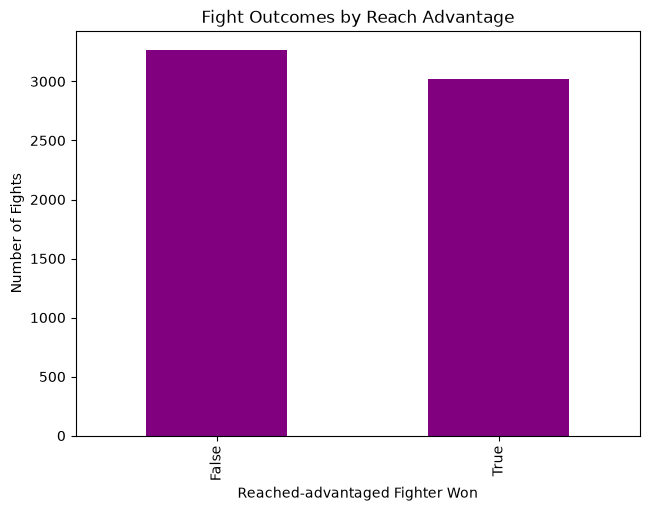

In [90]:
reach_advantage_counts.plot(kind='bar', color='purple')

plt.tight_layout()
plt.xlabel('Reached-advantaged Fighter Won')
plt.ylabel('Number of Fights')
plt.title('Fight Outcomes by Reach Advantage')
plt.show()

#### Findings

- Excluded fights where neither fighter had a reach advantage (`reach_dif == 0`).
- Among the remaining fights, the fighter with the reach advantage won **48.099%** of the time.
- The observed win rate (48.1%) is below 50%, suggesting that reach advantage alone does not provide an observable advantage in this dataset.
- The initial hypothesis is not supported by this analysis.

#### Conclusion

Based on this dataset, reach advantage alone does not appear to increase the probability of winning a UFC fight.

However, this analysis considers only reach difference in isolation. Other variables such as age, experience, betting odds, rankings, and weight class may interact with reach and should be investigated before drawing stronger conclusions.

### Investigation 2 - Age factor

#### Hypothesis
I believe younger fighters are more likely to win because they generally have better athleticism and recovery.

In [91]:
unequal_age_mask = ufc_data['R_age'] != ufc_data['B_age']

In [92]:
unequal_age_df = ufc_data[unequal_age_mask]
unequal_age_df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


#### Filter fights where younger fighter won

In [93]:
age_advantage_mask = ((unequal_age_df['R_age'] < unequal_age_df['B_age']) & (unequal_age_df['Winner'] == 'Red') | ((unequal_age_df['B_age'] < unequal_age_df['R_age']) & (unequal_age_df['Winner'] == 'Blue')))

In [94]:
age_advantage_counts = age_advantage_mask.value_counts()
print(age_advantage_counts)

True     3804
False    2831
Name: count, dtype: int64


#### Compute Empirical Probability

In [95]:
younger_fighter_win_rate = age_advantage_mask.mean()
print(younger_fighter_win_rate)

0.5733232856066315


#### Findings

- After excluding fights where both fighters were the same age, the younger fighter won approximately **57.3%** of the fights.
- This suggests that younger fighters have a higher observed win rate than older fighters.
- The effect appears stronger than the reach advantage investigated previously.

#### Conclusion

The results provide evidence that age is associated with fight outcomes. In this dataset, the younger fighter won more often than the older fighter.

However, age alone is unlikely to determine the outcome of a fight. Other factors such as experience, rankings, betting odds, and fighting style may also influence the result and should be investigated.

### Investigation 3 - Betting odds

#### Inspecting data

In [96]:
ufc_data[['R_odds', 'B_odds']].head(10)

,R_odds,B_odds
0,-130.0,102.0
1,124.0,-158.0
2,-901.0,550.0
3,235.0,-320.0
4,-158.0,124.0
5,-150.0,118.0
6,-295.0,220.0
7,-280.0,210.0
8,-104.0,-122.0
9,-113.0,-113.0


In [97]:
ufc_data[['R_odds', 'B_odds']].describe()

,R_odds,B_odds
count,6937.000000,6938.000000
mean,-114.380280,56.003459
std,285.370533,260.799641
min,-2100.000000,-2200.000000
25%,-255.000000,-150.000000
50%,-148.000000,130.000000
75%,130.000000,215.000000
max,1100.000000,1300.000000


In [98]:
ufc_data['R_odds'].value_counts().head(10)

R_odds
-200.0    114
-155.0    114
-130.0    109
-150.0    102
 130.0    101
-105.0    100
-110.0     98
-125.0     98
-140.0     98
-145.0     95
Name: count, dtype: int64

In [99]:
ufc_data[['R_fighter','B_fighter','R_odds', 'B_odds', 'Winner']].sample(10, random_state=42)

,R_fighter,B_fighter,R_odds,B_odds,Winner
3948,David Branch,Thiago Santos,140.0,-160.0,Red
2789,Khadis Ibragimov,Danilo Marques,-182.0,150.0,Blue
4988,Paul Felder,Daron Cruickshank,-240.0,200.0,Red
6081,John Makdessi,Renee Forte,-150.0,140.0,Red
1501,Ricky Glenn,Christos Giagos,-164.0,138.0,Blue
5196,Stevie Ray,Leonardo Mafra,-225.0,185.0,Red
6234,TJ Dillashaw,Hugo Viana,-320.0,290.0,Red
6275,Stefan Struve,Mark Hunt,-205.0,188.0,Blue
6982,Cody McKenzie,Aaron Wilkinson,-110.0,-110.0,Red
2692,Deiveson Figueiredo,Alex Perez,-286.0,225.0,Red


In [100]:
ufc_data[ufc_data["R_odds"] == ufc_data["B_odds"]]

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
9,Casey O'Neill,Gabriella Fernandes,-113.0,-113.0,88.4956,88.4956,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punches,1.0,3:11,191.0,175.0,150.0,2000.0,4000.0,2000.0,2000.0
189,Timmy Cuamba,ChangHo Lee,-108.0,-108.0,92.5926,92.5926,2025-11-01,"Las Vegas, Nevada, USA",USA,Red,...,NaN,3.0,5:00,900.0,170.0,260.0,2500.0,850.0,500.0,430.0
221,Charles Oliveira,Mateusz Gamrot,-108.0,-108.0,92.5926,92.5926,2025-10-11,"Rio de Janeiro, Rio de Janeiro, Brazil",Brazil,Red,...,Rear Naked Choke,2.0,2:48,468.0,650.0,310.0,300.0,600.0,2500.0,1800.0
337,Asu Almabayev,Jose Ochoa,-108.0,-108.0,92.5926,92.5926,2025-07-26,"Abu Dhabi, Abu Dhabi, United Arab Emirates",United Arab Emirates,Red,...,NaN,3.0,5:00,900.0,175.0,300.0,650.0,1200.0,1200.0,300.0
477,Timmy Cuamba,Roberto Romero,-108.0,-108.0,92.5926,92.5926,2025-04-26,"Kansas City, Missouri, USA",USA,Red,...,Flying Knee,2.0,3:55,535.0,160.0,210.0,5000.0,4000.0,1900.0,2900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6842,Daniel Roberts,Rich Attonito,-110.0,-110.0,90.9091,90.9091,2011-06-26,"Pittsburgh, Pennsylvania, USA",USA,Blue,...,NaN,3.0,5:00,900.0,NaN,NaN,NaN,NaN,NaN,NaN
6955,Waylon Lowe,Willamy Freire,-110.0,-110.0,90.9091,90.9091,2011-01-22,"Killeen, Texas, USA",USA,Red,...,NaN,3.0,5:00,900.0,NaN,NaN,NaN,NaN,NaN,NaN
6982,Cody McKenzie,Aaron Wilkinson,-110.0,-110.0,90.9091,90.9091,2010-12-04,"Las Vegas, Nevada, USA",USA,Red,...,Guillotine Choke,1.0,2:03,123.0,NaN,NaN,NaN,NaN,NaN,NaN
7018,Chris Camozzi,Dongi Yang,-110.0,-110.0,90.9091,90.9091,2010-10-23,"Anaheim, California, USA",USA,Red,...,NaN,3.0,5:00,900.0,NaN,NaN,NaN,NaN,NaN,NaN


#### Hypothesis

I believe the fighter with lower betting odds, i.e., the favoured fighter is more likely to win.

In [101]:
non_equal_odds_df = ufc_data[ufc_data["R_odds"] != ufc_data["B_odds"]]

#### Filtering fights where favoured fighter won

In [102]:
favourite_fighter_mask = (((non_equal_odds_df['R_odds'] < non_equal_odds_df['B_odds']) & (non_equal_odds_df['Winner'] == 'Red')) | (non_equal_odds_df['R_odds'] > non_equal_odds_df['B_odds']) & (non_equal_odds_df['Winner'] == 'Blue'))

#### Calculating Empirical Probability

In [103]:
favourite_fighter_win_rate = favourite_fighter_mask.mean()
print (favourite_fighter_win_rate)

0.6410656086155591


#### Plot

In [104]:
favourite_fighter_counts = favourite_fighter_mask.value_counts()

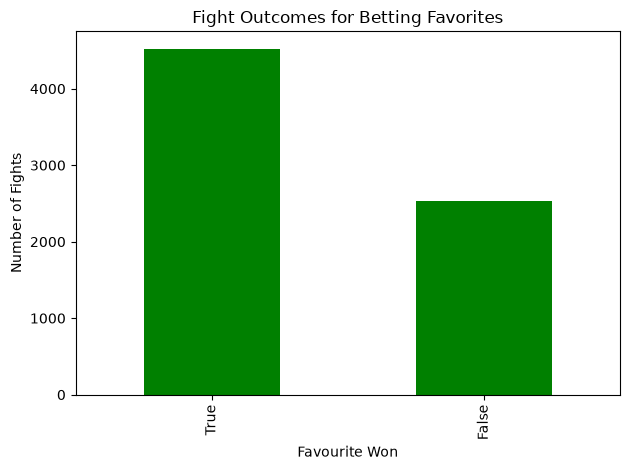

In [105]:
favourite_fighter_counts.plot(kind="bar", color = 'green')
favourite_fighter_counts.index = ["Underdog Won", "Favourite Won"]

plt.xlabel("Favourite Won")
plt.ylabel("Number of Fights")
plt.title("Fight Outcomes for Betting Favorites")

plt.tight_layout()
plt.show()

#### Findings
- After excluding fights with equal betting odds, the betting favorite won approximately **64.1%** of the fights.
- This is the strongest predictor investigated so far.
- Although betting favorites win more often than underdogs, upsets still occur in roughly one-third of fights.

#### Conclusion
Betting odds provide a stronger signal than reach or age alone. This suggests that betting markets successfully aggregate information about fighters before a bout. However, betting odds are not perfect predictors, as underdogs still win a substantial proportion of fights.

### Investigation 4 - Rank Advantage

#### Hypothesis
I believe higher ranked fighters are more likely to win because of superior performance.

#### Inspecting the data

In [106]:
ufc_data[
    [
        'better_rank', 'R_match_weightclass_rank', 'B_match_weightclass_rank'
    ]
].head()

,better_rank,R_match_weightclass_rank,B_match_weightclass_rank
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


In [107]:
ufc_data[
    [
        "R_match_weightclass_rank",
        "B_match_weightclass_rank",
        "better_rank"
    ]
].isna().sum()

R_match_weightclass_rank    5202
B_match_weightclass_rank    5845
better_rank                  436
dtype: int64

In [108]:
ufc_data["better_rank"].value_counts(dropna=False)

better_rank
neither    4695
Red        1946
NaN         436
Blue        100
Name: count, dtype: int64

In [109]:
ufc_data["better_rank"].unique()

<StringArray>
[nan, 'Red', 'Blue', 'neither']
Length: 4, dtype: str

In [110]:
ufc_data.loc[
    ufc_data["better_rank"] == "Red",
    [
        "R_match_weightclass_rank",
        "B_match_weightclass_rank",
        "better_rank"
    ]
].head(10)

,R_match_weightclass_rank,B_match_weightclass_rank,better_rank
13,1.0,3.0,Red
15,13.0,NaN,Red
17,11.0,NaN,Red
26,11.0,14.0,Red
27,5.0,8.0,Red
31,14.0,NaN,Red
41,7.0,8.0,Red
42,13.0,NaN,Red
44,13.0,15.0,Red
52,6.0,NaN,Red


In [111]:
ufc_data.loc[
    ufc_data["better_rank"] == "Blue",
    [
        "R_match_weightclass_rank",
        "B_match_weightclass_rank",
        "better_rank"
    ]
].head(10)

,R_match_weightclass_rank,B_match_weightclass_rank,better_rank
40,4.0,3.0,Blue
107,NaN,8.0,Blue
125,NaN,15.0,Blue
146,NaN,11.0,Blue
183,NaN,9.0,Blue
372,NaN,2.0,Blue
413,NaN,14.0,Blue
679,NaN,11.0,Blue
750,NaN,11.0,Blue
785,NaN,8.0,Blue


In [112]:
ufc_data.loc[
    ufc_data["better_rank"] == "neither",
    [
        "R_match_weightclass_rank",
        "B_match_weightclass_rank",
        "better_rank"
    ]
].head(10)

,R_match_weightclass_rank,B_match_weightclass_rank,better_rank
637,NaN,NaN,neither
639,NaN,NaN,neither
640,NaN,NaN,neither
641,NaN,NaN,neither
642,NaN,NaN,neither
643,NaN,NaN,neither
644,NaN,NaN,neither
645,NaN,NaN,neither
646,NaN,NaN,neither
647,NaN,NaN,neither
